In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df= pd.read_csv( r"C:\Users\Harsh\Downloads\Project Dataset ev fleet.csv")
df.head()

,Date_Time,Vehicle_ID,Battery_Capacity_kWh,State_of_Charge_%,Energy_Consumption_Rate_kWh/km,Current_Latitude,Current_Longitude,Destination_Latitude,Destination_Longitude,Distance_to_Destination_km,...,Session_Start_Hour,Fleet_Size,Fleet_Schedule,Temperature_C,Wind_Speed_m/s,Precipitation_mm,Weekday,Charging_Preferences,Weather_Conditions,Charging_Load_kW
0,2017-01-01 00:00:00,106.0,66.746483,50.216524,0.153521,32.777266,-96.788301,32.784014,-96.795776,30.531144,...,6.0,10.0,0.0,13.954368,0.144765,0.712211,1.0,0.0,Cloudy,30.839677
1,2017-01-01 01:00:00,106.0,NaN,59.358609,0.119101,NaN,-96.786137,32.778406,-96.798310,1.004305,...,6.0,10.0,0.0,38.926466,0.461061,2.746260,3.0,0.0,Cloudy,47.354691
2,2017-01-01 02:00:00,106.0,82.107913,14.460831,0.100000,32.769346,-96.802470,32.770487,-96.795953,5.289772,...,6.0,50.0,0.0,22.164516,0.708376,2.502156,4.0,1.0,Clear,44.459198
3,2017-01-01 03:00:00,106.0,95.526752,23.003923,0.286505,32.766093,-96.790229,32.765745,-96.818855,7.267380,...,6.0,200.0,0.0,16.000845,1.591273,1.796916,3.0,0.0,Clear,52.468801
4,2017-01-01 04:00:00,106.0,61.247597,9.064810,NaN,32.796174,-96.782421,32.765489,-96.791241,32.449058,...,6.0,10.0,1.0,23.170368,1.753500,1.547112,2.0,0.0,Clear,53.473756


In [3]:
print(df.shape)

(64945, 28)


In [4]:
print(df.columns)

Index(['Date_Time', 'Vehicle_ID', 'Battery_Capacity_kWh', 'State_of_Charge_%',
       'Energy_Consumption_Rate_kWh/km', 'Current_Latitude',
       'Current_Longitude', 'Destination_Latitude', 'Destination_Longitude',
       'Distance_to_Destination_km', 'Traffic_Data', 'Road_Conditions',
       'Charging_Station_ID', 'Charging_Rate_kW', 'Queue_Time_mins',
       'Station_Capacity_EV', 'Time_Spent_Charging_mins', 'Energy_Drawn_kWh',
       'Session_Start_Hour', 'Fleet_Size', 'Fleet_Schedule', 'Temperature_C',
       'Wind_Speed_m/s', 'Precipitation_mm', 'Weekday', 'Charging_Preferences',
       'Weather_Conditions', 'Charging_Load_kW'],
      dtype='object')


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64945 entries, 0 to 64944
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date_Time                       59716 non-null  object 
 1   Vehicle_ID                      59669 non-null  float64
 2   Battery_Capacity_kWh            59853 non-null  float64
 3   State_of_Charge_%               59733 non-null  float64
 4   Energy_Consumption_Rate_kWh/km  59748 non-null  float64
 5   Current_Latitude                59735 non-null  float64
 6   Current_Longitude               59702 non-null  float64
 7   Destination_Latitude            59828 non-null  float64
 8   Destination_Longitude           59804 non-null  float64
 9   Distance_to_Destination_km      59794 non-null  float64
 10  Traffic_Data                    59855 non-null  float64
 11  Road_Conditions                 59846 non-null  object 
 12  Charging_Station_ID             

In [6]:
print(df.describe())

       Vehicle_ID  Battery_Capacity_kWh  State_of_Charge_%  \
count     59669.0          59853.000000       59733.000000   
mean        106.0             74.716975          28.448464   
std           0.0             14.347540          15.928202   
min         106.0             30.000000           0.099346   
25%         106.0             64.923266          15.947327   
50%         106.0             74.966248          26.381701   
75%         106.0             85.145052          38.821120   
max         106.0            100.000000          89.662865   

       Energy_Consumption_Rate_kWh/km  Current_Latitude  Current_Longitude  \
count                    59748.000000      59735.000000       59702.000000   
mean                         0.177172         32.776673         -96.797063   
std                          0.083463          0.010070           0.009970   
min                          0.100000         32.735193         -96.838816   
25%                          0.100000         32.76

In [7]:
df.isnull().sum()

Date_Time                         5229
Vehicle_ID                        5276
Battery_Capacity_kWh              5092
State_of_Charge_%                 5212
Energy_Consumption_Rate_kWh/km    5197
Current_Latitude                  5210
Current_Longitude                 5243
Destination_Latitude              5117
Destination_Longitude             5141
Distance_to_Destination_km        5151
Traffic_Data                      5090
Road_Conditions                   5099
Charging_Station_ID               5141
Charging_Rate_kW                  5230
Queue_Time_mins                   5243
Station_Capacity_EV               5219
Time_Spent_Charging_mins          5180
Energy_Drawn_kWh                  5143
Session_Start_Hour                5282
Fleet_Size                        5220
Fleet_Schedule                    5089
Temperature_C                     5323
Wind_Speed_m/s                    5281
Precipitation_mm                  5194
Weekday                           5209
Charging_Preferences     

In [8]:
df = df.fillna(df.mean(numeric_only=True))

In [9]:
df["Weather_Conditions"].fillna(df["Weather_Conditions"].mode()[0], inplace=True)
df["Road_Conditions"].fillna(df["Road_Conditions"].mode()[0], inplace=True)

C:\Users\Harsh\AppData\Local\Temp\ipykernel_16996\308245145.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Weather_Conditions"].fillna(df["Weather_Conditions"].mode()[0], inplace=True)
C:\Users\Harsh\AppData\Local\Temp\ipykernel_16996\308245145.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

In [10]:
df["Date_Time"].fillna(method="ffill", inplace=True)
df["Date_Time"] = pd.to_datetime(df["Date_Time"], errors="coerce")

C:\Users\Harsh\AppData\Local\Temp\ipykernel_16996\3810179593.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Date_Time"].fillna(method="ffill", inplace=True)
C:\Users\Harsh\AppData\Local\Temp\ipykernel_16996\3810179593.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["Date_Time"].fillna(method="ffill", inplace=True)


In [11]:
df.isnull().sum()

Date_Time                         0
Vehicle_ID                        0
Battery_Capacity_kWh              0
State_of_Charge_%                 0
Energy_Consumption_Rate_kWh/km    0
Current_Latitude                  0
Current_Longitude                 0
Destination_Latitude              0
Destination_Longitude             0
Distance_to_Destination_km        0
Traffic_Data                      0
Road_Conditions                   0
Charging_Station_ID               0
Charging_Rate_kW                  0
Queue_Time_mins                   0
Station_Capacity_EV               0
Time_Spent_Charging_mins          0
Energy_Drawn_kWh                  0
Session_Start_Hour                0
Fleet_Size                        0
Fleet_Schedule                    0
Temperature_C                     0
Wind_Speed_m/s                    0
Precipitation_mm                  0
Weekday                           0
Charging_Preferences              0
Weather_Conditions                0
Charging_Load_kW            

In [12]:
df["hour"] = df["Date_Time"].dt.hour
df["day"] = df["Date_Time"].dt.day

In [13]:
df.head()

,Date_Time,Vehicle_ID,Battery_Capacity_kWh,State_of_Charge_%,Energy_Consumption_Rate_kWh/km,Current_Latitude,Current_Longitude,Destination_Latitude,Destination_Longitude,Distance_to_Destination_km,...,Fleet_Schedule,Temperature_C,Wind_Speed_m/s,Precipitation_mm,Weekday,Charging_Preferences,Weather_Conditions,Charging_Load_kW,hour,day
0,2017-01-01 00:00:00,106.0,66.746483,50.216524,0.153521,32.777266,-96.788301,32.784014,-96.795776,30.531144,...,0.0,13.954368,0.144765,0.712211,1.0,0.0,Cloudy,30.839677,0,1
1,2017-01-01 01:00:00,106.0,74.716975,59.358609,0.119101,32.776673,-96.786137,32.778406,-96.798310,1.004305,...,0.0,38.926466,0.461061,2.746260,3.0,0.0,Cloudy,47.354691,1,1
2,2017-01-01 02:00:00,106.0,82.107913,14.460831,0.100000,32.769346,-96.802470,32.770487,-96.795953,5.289772,...,0.0,22.164516,0.708376,2.502156,4.0,1.0,Clear,44.459198,2,1
3,2017-01-01 03:00:00,106.0,95.526752,23.003923,0.286505,32.766093,-96.790229,32.765745,-96.818855,7.267380,...,0.0,16.000845,1.591273,1.796916,3.0,0.0,Clear,52.468801,3,1
4,2017-01-01 04:00:00,106.0,61.247597,9.064810,0.177172,32.796174,-96.782421,32.765489,-96.791241,32.449058,...,1.0,23.170368,1.753500,1.547112,2.0,0.0,Clear,53.473756,4,1


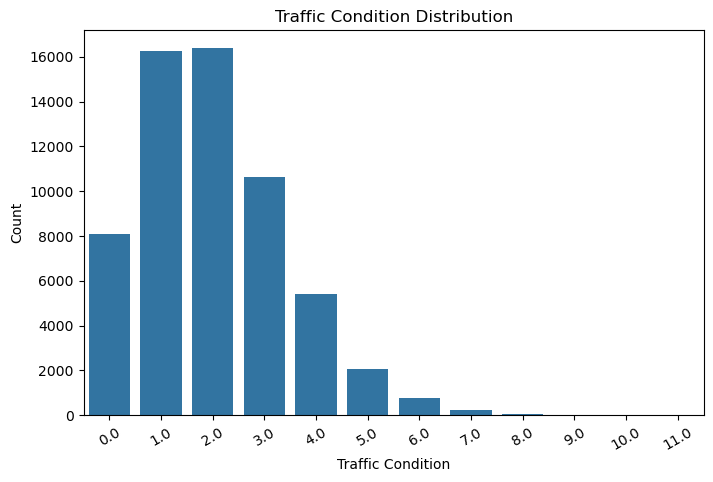

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(x="Traffic_Data", data=df)

plt.title("Traffic Condition Distribution")
plt.xlabel("Traffic Condition")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

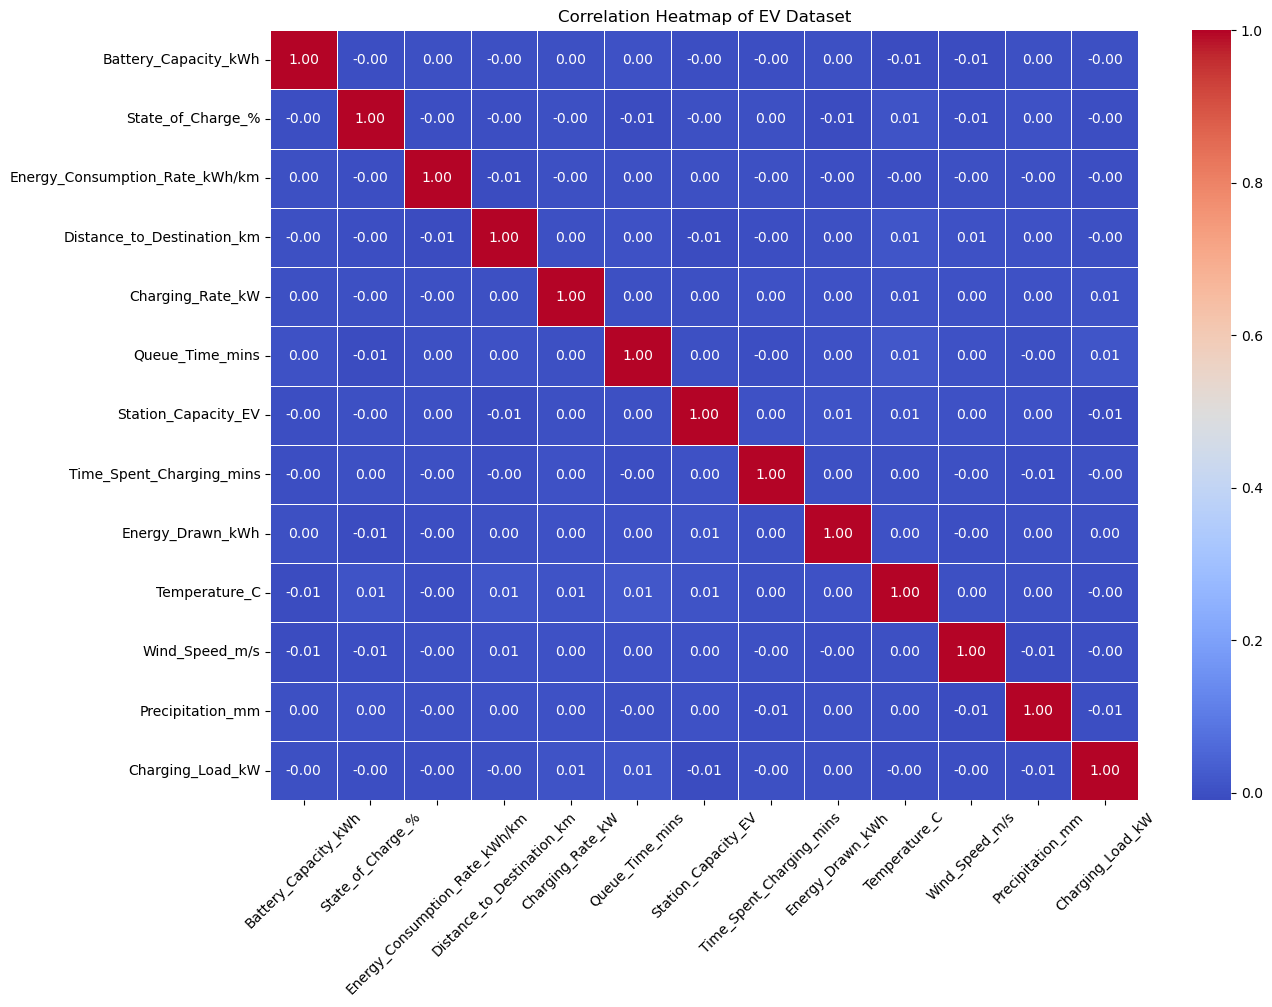

In [16]:
plt.figure(figsize=(14,10))

numeric_cols = [
'Battery_Capacity_kWh',
'State_of_Charge_%',
'Energy_Consumption_Rate_kWh/km',
'Distance_to_Destination_km',
'Charging_Rate_kW',
'Queue_Time_mins',
'Station_Capacity_EV',
'Time_Spent_Charging_mins',
'Energy_Drawn_kWh',
'Temperature_C',
'Wind_Speed_m/s',
'Precipitation_mm',
'Charging_Load_kW'
]

corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of EV Dataset")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

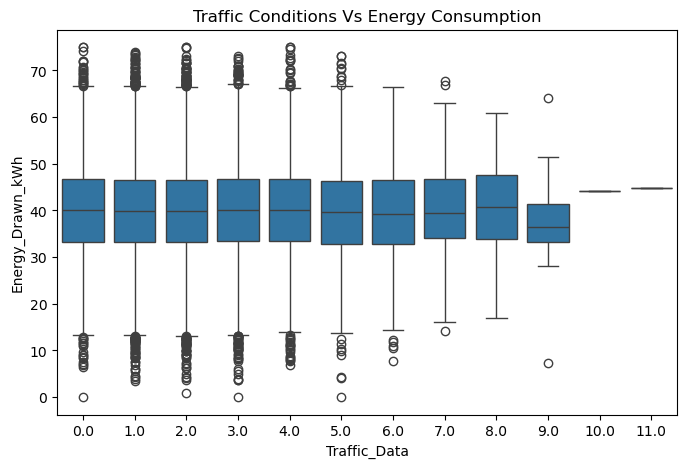

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Traffic_Data", y="Energy_Drawn_kWh", data=df)
plt.title("Traffic Conditions Vs Energy Consumption")
plt.show()

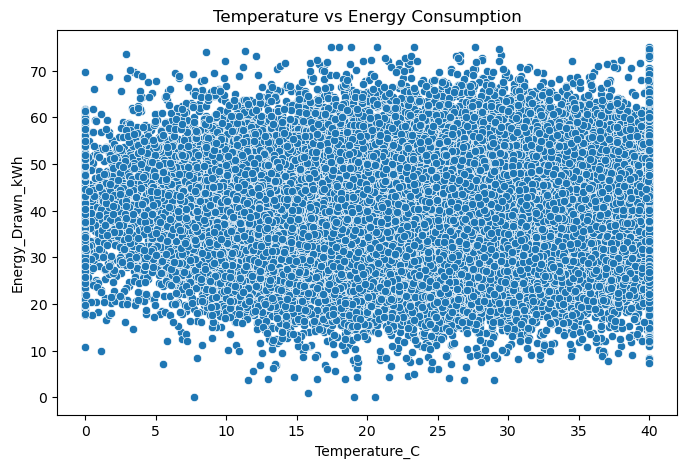

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Temperature_C", y="Energy_Drawn_kWh", data=df)
plt.title("Temperature vs Energy Consumption")
plt.show()

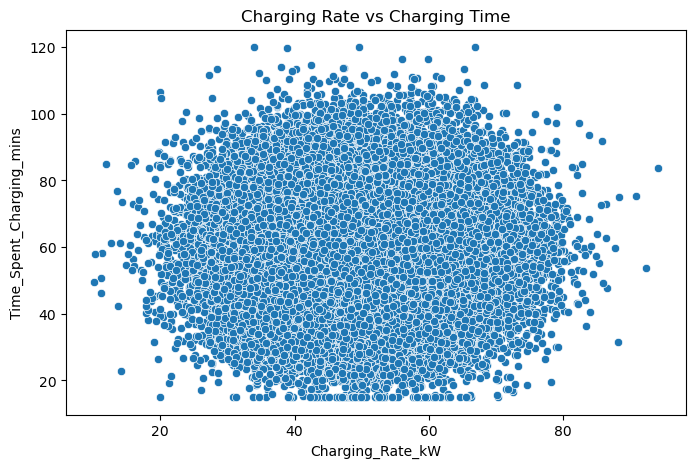

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Charging_Rate_kW', y='Time_Spent_Charging_mins', data=df)
plt.title("Charging Rate vs Charging Time")
plt.show()

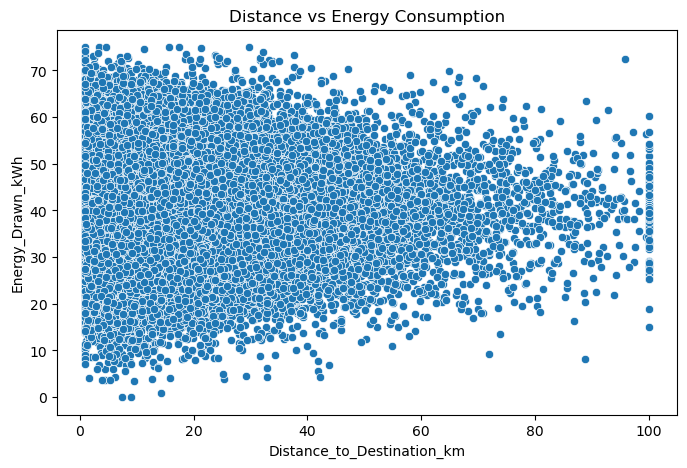

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Distance_to_Destination_km', y='Energy_Drawn_kWh', data=df)
plt.title("Distance vs Energy Consumption")
plt.show()

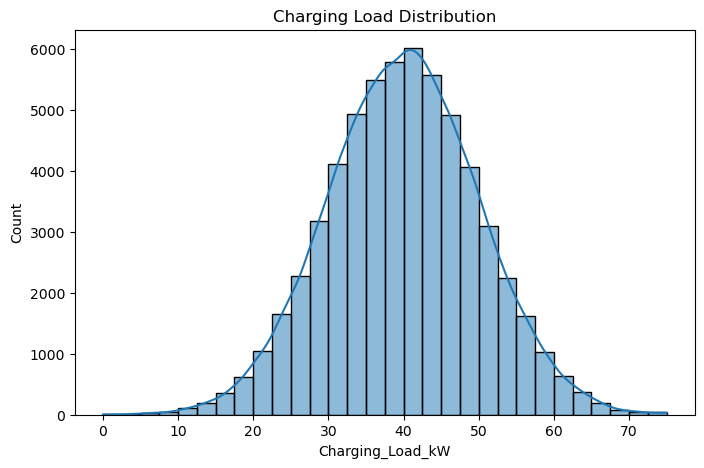

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Charging_Load_kW'], bins=30, kde=True)
plt.title("Charging Load Distribution")
plt.show()

In [23]:
df["hour"] = pd.to_datetime(df["Date_Time"], errors="coerce").dt.hour
df["day"] = pd.to_datetime(df["Date_Time"], errors="coerce").dt.day

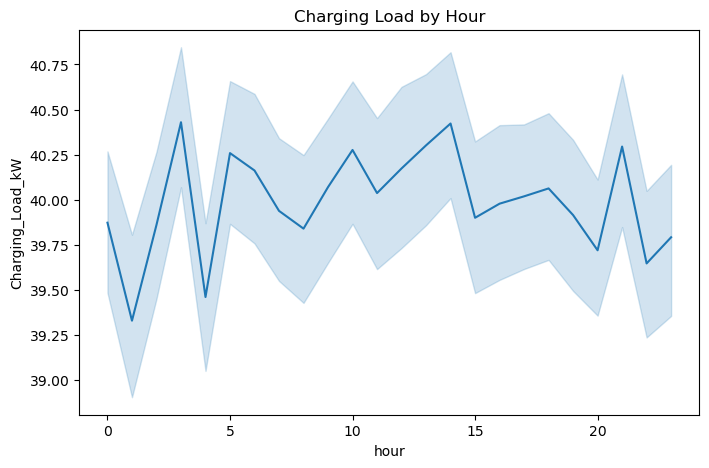

In [24]:
plt.figure(figsize=(8,5))
sns.lineplot(x='hour', y='Charging_Load_kW', data=df)
plt.title("Charging Load by Hour")
plt.show()

In [25]:
df = df.drop(columns=['Date_Time'], errors='ignore')

In [26]:
X = df.drop("Charging_Load_kW", axis=1)
y = df["Charging_Load_kW"]

In [27]:
X = pd.get_dummies(X)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.24, random_state=42)


In [36]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

y_train = y_train.fillna(0)
y_test = y_test.fillna(0)

In [39]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit + transform
X_test = scaler.transform(X_test)         # sirf transform

In [49]:
model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=10)

In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=7),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

In [51]:
print(y.describe())

count    64945.000000
mean        36.753117
std         14.493258
min          0.000000
25%         30.993932
50%         38.889535
75%         46.010105
max         75.000000
Name: Charging_Load_kW, dtype: float64


In [47]:
X = X.fillna(0)

In [52]:
accuracy = (1 - abs(r2)) * 100

In [48]:
y = y.fillna(0)

In [53]:
results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    r2 = r2_score(y_test, predictions)
    
    accuracy = (1 - abs(r2)) * 100
    
    results[name] = accuracy
    
    print(name, "Accuracy:", round(accuracy,2), "%")

Linear Regression Accuracy: 99.91 %
Decision Tree Accuracy: 99.49 %
Random Forest Accuracy: 99.91 %
KNN Accuracy: 80.04 %


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [58]:
results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    
    results[name] = [mae, mse, rmse, r2]
    
    print(f"\n{name}")
    print("MAE:", round(mae,2))
    print("MSE:", round(mse,2))
    print("RMSE:", round(rmse,2))


Linear Regression
MAE: 10.65
MSE: 211.43
RMSE: 14.54

Decision Tree
MAE: 10.68
MSE: 212.33
RMSE: 14.57

Random Forest
MAE: 10.65
MSE: 211.55
RMSE: 14.54

KNN
MAE: 11.96
MSE: 253.41
RMSE: 15.92


In [56]:
best_model = max(results, key=lambda x: results[x][3])  # R2 ke basis pe

print("\nBest Model:", best_model)


Best Model: Linear Regression


In [57]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

print("Predicted Value:", prediction)
print("Actual Value:", y_test.iloc[0])

Predicted Value: [34.86906193]
Actual Value: 54.16061956960317


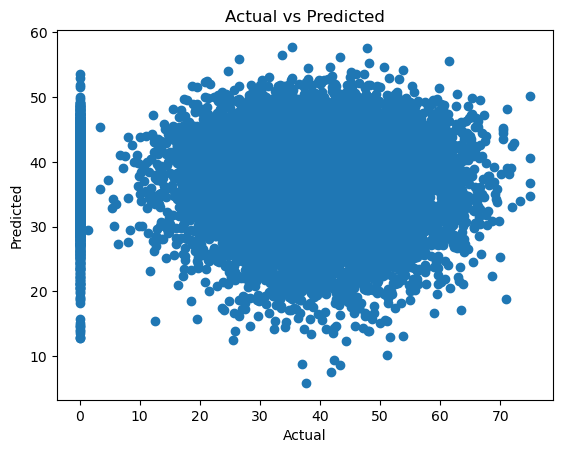

In [59]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()